## Environment Setup and Data Ingestion
Loads necessary libraries and points to the specific file location.

In [18]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MultipleLocator
from pathlib import Path

# Path relative to phase2_linear.ipynb
file_path = 'artifacts/case2_phase1/case2_phase1_bundle.pkl'

FIG_DIR = Path('figures/case2_phase2')
# Load the data bundle
data_matrix = joblib.load(file_path)
bundle = data_matrix

# Mapping variables for clear access
X = data_matrix['X']
X_subjz = data_matrix['X_subjz']
y_phase = data_matrix['y_phase']
subjects = data_matrix['subject']
features = data_matrix['feature_cols']

print(f"Data loaded from {file_path}")
print(f"Dataset contains {X.shape[0]} samples and {len(features)} features.")

Data loaded from artifacts/case2_phase1/case2_phase1_bundle.pkl
Dataset contains 312 samples and 51 features.


## Impact of Subject-Normalization
Compare PCA projections before and after Z-scoring by subject. This demonstrates that normalization is required to remove individual baseline differences and reveal the experimental effect.

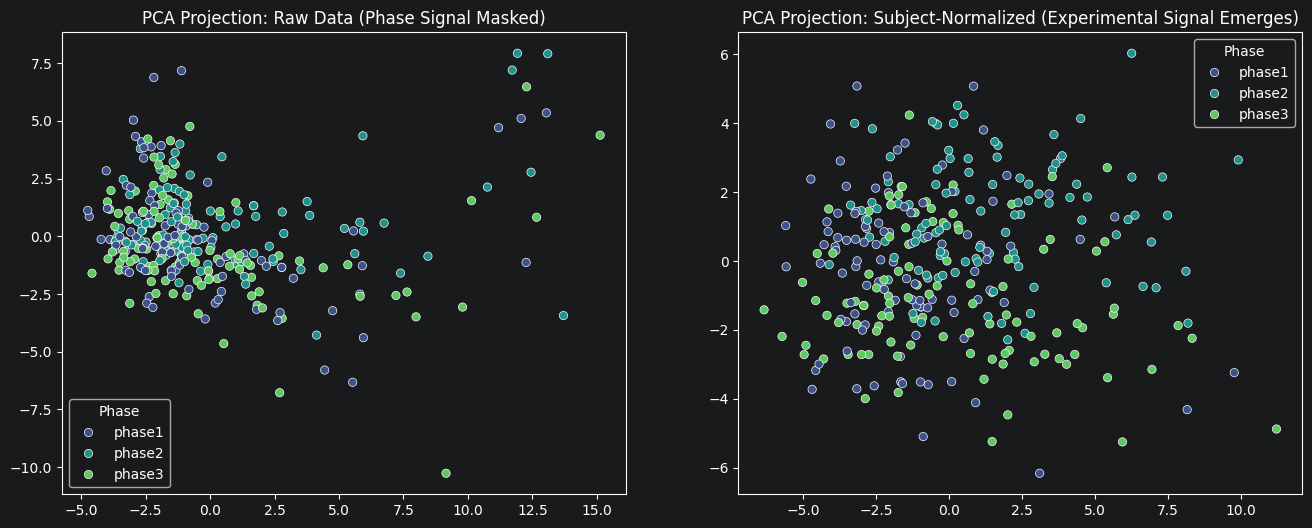

In [19]:

# 1. Fit PCA on Raw vs Normalized
pca_raw = PCA().fit(X)
X_pca_raw = pca_raw.transform(X)

pca_subj = PCA().fit(X_subjz)
X_pca_subj = pca_subj.transform(X_subjz)

# 2. Comparison Plot
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=X_pca_raw[:,0], y=X_pca_raw[:,1], hue=y_phase, ax=ax[0], palette='viridis')
ax[0].set_title('PCA Projection: Raw Data (Phase Signal Masked)')

sns.scatterplot(x=X_pca_subj[:,0], y=X_pca_subj[:,1], hue=y_phase, ax=ax[1], palette='viridis')
ax[1].set_title('PCA Projection: Subject-Normalized (Experimental Signal Emerges)')
plt.savefig(FIG_DIR / 'p2_raw_vs_normalized.png', format='png', bbox_inches='tight')
plt.show()

## Dimensionality and Variance Analysis
Using a scree plot and a cumulative variance step plot to determine the optimal number of components for analysis.

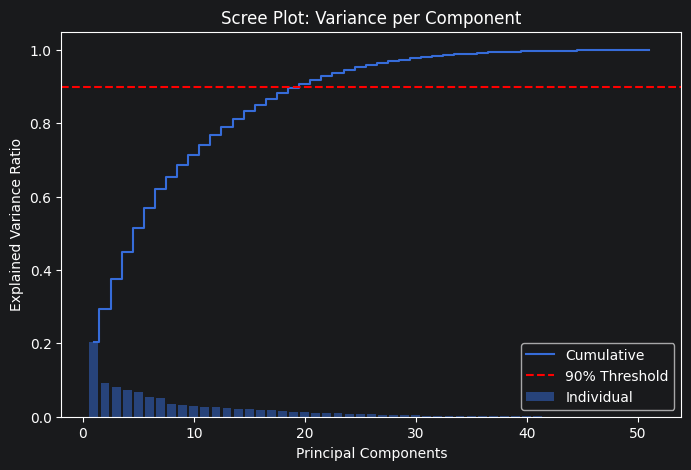

Number of components needed to reach 90% variance: 20


In [20]:
# Calculate cumulative variance
cum_var = np.cumsum(pca_subj.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(cum_var) + 1), pca_subj.explained_variance_ratio_, alpha=0.5, label='Individual')
plt.step(range(1, len(cum_var) + 1), cum_var, where='mid', label='Cumulative')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot: Variance per Component')
plt.legend()
plt.savefig(FIG_DIR /'p2_cumulative_variance.png', format='png', bbox_inches='tight')
plt.show()

# Identify components for 90% threshold
n_90 = np.argmax(cum_var >= 0.9) + 1
print(f"Number of components needed to reach 90% variance: {n_90}")

## 3D Global Visualization
A 3D projection provides a holistic view of the data "cloud," showing how phases occupy different regions of the feature space.

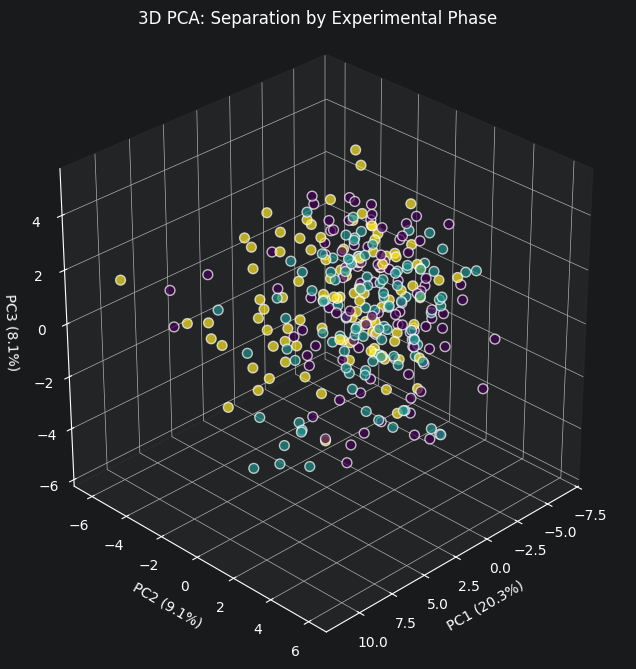

In [21]:
# Fit PCA with 3 components for visualization
pca_3 = PCA(n_components=3)
X_pca_3d = pca_3.fit_transform(X_subjz)
v = pca_3.explained_variance_ratio_

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Phase mapping
colors_phase = {'phase1': '#440154', 'phase2': '#21918c', 'phase3': '#fde725'}
c_phase = [colors_phase[p] for p in y_phase]

ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=c_phase, alpha=0.7, s=50, edgecolors='w')

ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=30, azim=45)

ax.set_xlabel(f'PC1 ({v[0]:.1%})')
ax.set_ylabel(f'PC2 ({v[1]:.1%})')
ax.set_zlabel(f'PC3 ({v[2]:.1%})')
ax.set_title('3D PCA: Separation by Experimental Phase')
plt.savefig(FIG_DIR /'p2_pca_3d_projection.png', format='png', bbox_inches='tight')
plt.show()

## Squared 2D Pairwise Projections
These plots provide the technical precision required for the report. The 1-unit grid and square aspect ratio allow for objective comparison of distances between clusters.

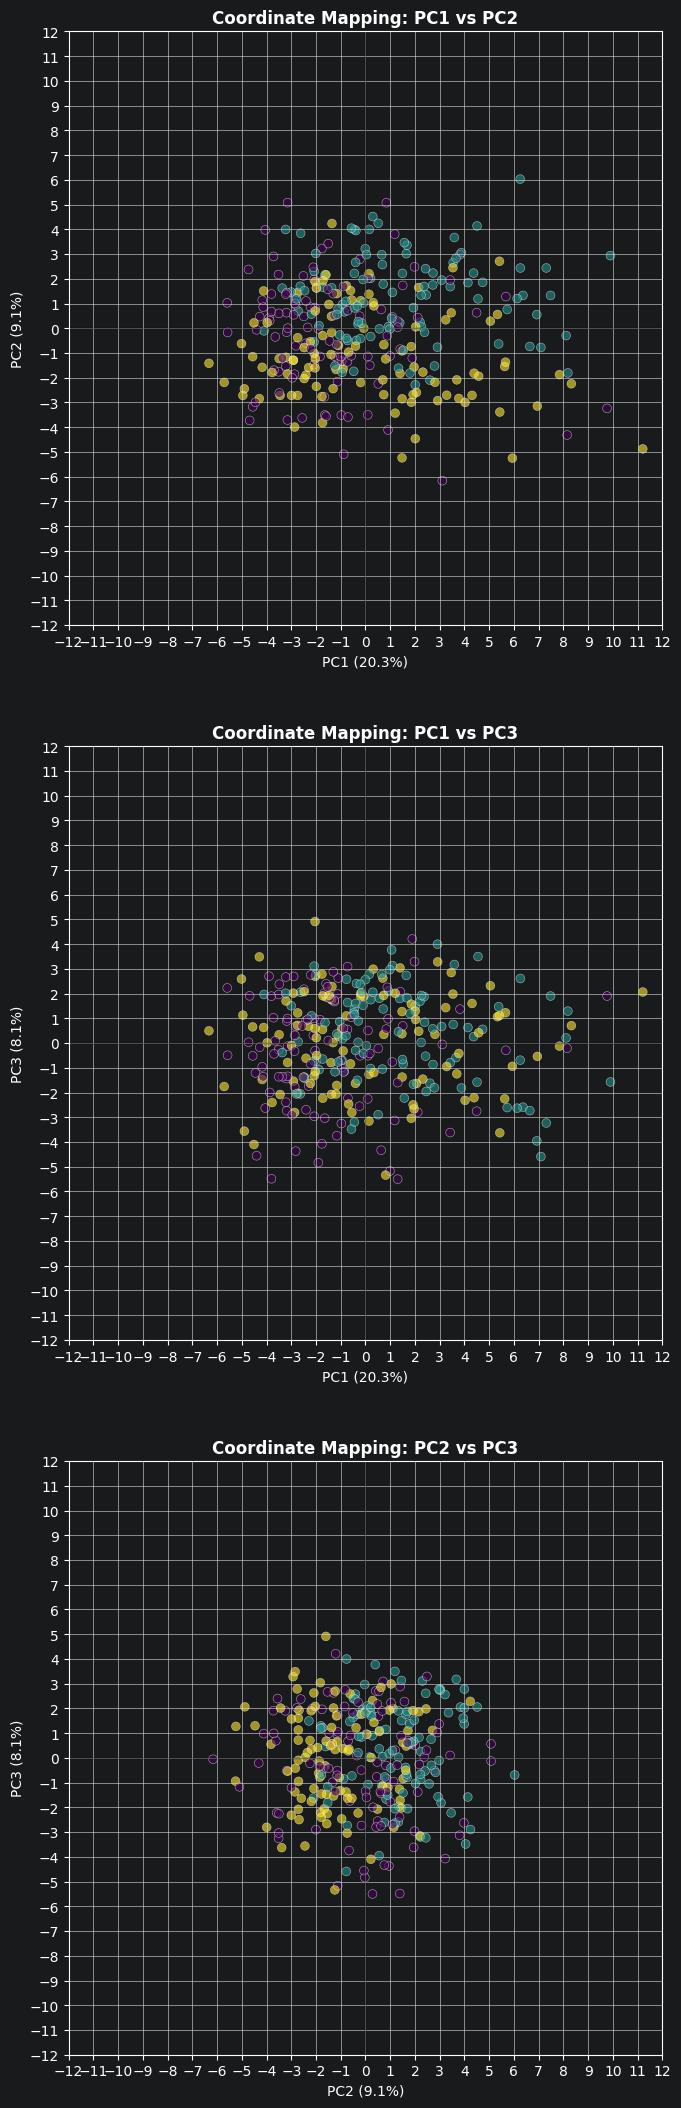

In [22]:
pairs = [(0, 1), (0, 2), (1, 2)]
fig, axes = plt.subplots(3, 1, figsize=(8, 22))
zoom_limit = 12

for i, (pc_a, pc_b) in enumerate(pairs):
    ax = axes[i]
    ax.scatter(X_pca_3d[:, pc_a], X_pca_3d[:, pc_b], c=c_phase, alpha=0.6, s=40, edgecolors='w', linewidth=0.4)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-zoom_limit, zoom_limit)
    ax.set_ylim(-zoom_limit, zoom_limit)

    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.grid(True, which='major', linestyle='-', color='#e0e0e0', alpha=0.8, linewidth=0.5)

    ax.axhline(0, color='black', lw=1, alpha=0.4)
    ax.axvline(0, color='black', lw=1, alpha=0.4)

    ax.set_xlabel(f'PC{pc_a+1} ({v[pc_a]:.1%})')
    ax.set_ylabel(f'PC{pc_b+1} ({v[pc_b]:.1%})')
    ax.set_title(f'Coordinate Mapping: PC{pc_a+1} vs PC{pc_b+1}', fontweight='bold')

plt.tight_layout(pad=4.0)
plt.savefig(FIG_DIR /'p2_pca_2d_projection.png', format='png', bbox_inches='tight')
plt.show()

## Component Loading Analysis
This cell identifies the biological features (sensors) that define the direction of each principal component.

In [23]:
loadings_3pc = pd.DataFrame(pca_3.components_.T, columns=['PC1', 'PC2', 'PC3'], index=features)

def analyze_pc(pc_name):
    idx = int(pc_name[-1]) - 1
    print(f"\n{'='*20} {pc_name} ({v[idx]:.1%} Variance) {'='*20}")
    top_pos = loadings_3pc[pc_name].sort_values(ascending=False).head(5)
    top_neg = loadings_3pc[pc_name].sort_values(ascending=True).head(5)

    print(f"TOP POSITIVE (Associated with Phase 2/Puzzle):")
    print(top_pos)
    print(f"\nTOP NEGATIVE (Associated with Recovery/Baseline):")
    print(top_neg)

for pc in ['PC1', 'PC2', 'PC3']:
    analyze_pc(pc)


==================== PC1 (20.3% Variance) ====================
TOP POSITIVE (Associated with Phase 2/Puzzle):
EDA_TD_P_Mean         0.285308
EDA_TD_P_AUC          0.285099
EDA_TD_P_std          0.278089
EDA_TD_P_Max          0.267281
EDA_TD_T_Slope_max    0.243878
Name: PC1, dtype: float64

TOP NEGATIVE (Associated with Recovery/Baseline):
EDA_TD_P_Slope_min   -0.250488
EDA_TD_T_Slope_min   -0.218300
EDA_TD_P_Skew        -0.136395
EDA_TD_P_Kurtosis    -0.134564
EDA_TD_P_ReT         -0.092325
Name: PC1, dtype: float64

==================== PC2 (9.1% Variance) ====================
TOP POSITIVE (Associated with Phase 2/Puzzle):
HR_TD_Mean      0.319066
HR_TD_Max       0.318599
HR_TD_AUC       0.283232
HR_TD_std       0.277785
HR_TD_Median    0.259600
Name: PC2, dtype: float64

TOP NEGATIVE (Associated with Recovery/Baseline):
HR_TD_Slope_min   -0.190798
EDA_TD_T_Max      -0.171226
EDA_TD_P_RT       -0.160252
EDA_TD_P_Skew     -0.158047
EDA_TD_T_Mean     -0.154371
Name: PC2, dtype: float6

## Physiological Feature Validation
A final verification to see how the top-contributing sensors from the PCA actually change across the three phases.

In [24]:
# Create a temporary DataFrame for phase-wise means
df_val = pd.DataFrame(X_subjz, columns=features)
df_val['Phase'] = y_phase

# Select the top feature from PC1 for validation
top_feature = loadings_3pc['PC1'].idxmax()

phase_means = df_val.groupby('Phase')[top_feature].mean()
print(f"Validation: Mean of {top_feature} per Phase (Z-scored)")
print(phase_means)

Validation: Mean of EDA_TD_P_Mean per Phase (Z-scored)
Phase
phase1   -0.435737
phase2    0.458806
phase3   -0.023069
Name: EDA_TD_P_Mean, dtype: float64


## MANOVA (Multivariate Analysis of Variance)
We use the 3 Principal Components to prove the experimental phases are statistically distinct.

In [25]:
from statsmodels.multivariate.manova import MANOVA

# Prepare the data for MANOVA
df_manova = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_manova['Phase'] = y_phase

# Fit the MANOVA model
maov = MANOVA.from_formula('PC1 + PC2 + PC3 ~ Phase', data=df_manova)
print("--- MANOVA Results: Phase Effect on Physiology ---")
print(maov.mv_test())

--- MANOVA Results: Phase Effect on Physiology ---
                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9171 3.0000 307.0000  9.2503 0.0000
         Pillai's trace 0.0829 3.0000 307.0000  9.2503 0.0000
 Hotelling-Lawley trace 0.0904 3.0000 307.0000  9.2503 0.0000
    Roy's greatest root 0.0904 3.0000 307.0000  9.2503 0.0000
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
         Phase          Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.6775 6.0000 614.0000 21.9886 0.0000
         Pillai's trace 0.3414 6.0000

## Post-hoc Anova (specific PC3 Drift)
Testing if Phase 3 (Recovery) is statistically different from Phase 1 (Baseline) on the Thermal axis.

In [26]:
import scipy.stats as stats

# ANOVA for PC3
f_stat, p_val = stats.f_oneway(
    df_manova[df_manova['Phase']=='phase1']['PC3'],
    df_manova[df_manova['Phase']=='phase2']['PC3'],
    df_manova[df_manova['Phase']=='phase3']['PC3']
)

print(f"ANOVA Result for PC3: F={f_stat:.4f}, p={p_val:.4f}")

# Direct T-test comparison for Phase 1 vs Phase 3
t_stat, t_p = stats.ttest_ind(
    df_manova[df_manova['Phase']=='phase1']['PC3'],
    df_manova[df_manova['Phase']=='phase3']['PC3']
)
print(f"Post-hoc T-test (Phase 1 vs Phase 3): p={t_p:.4f}")

ANOVA Result for PC3: F=2.9791, p=0.0523
Post-hoc T-test (Phase 1 vs Phase 3): p=0.2009


## Canonical Correlation Analysis (CCA) - Physiology vs. Qualitative
Connecting the 47 physiological features to the qualitative metrics (frustrated and panas).

In [27]:
from sklearn.cross_decomposition import CCA
import pandas as pd

# 1. Align the Physical (X) and Emotional (Y) observations
df_cca = pd.DataFrame(X_subjz, columns=features)

# Add the single-column frustration score
df_cca['frustrated'] = bundle['frustrated']

# Join the multi-column PANAS DataFrame (Positive/Negative scores)
# This handles the "multiple columns" issue by joining correctly
df_cca = df_cca.join(bundle['panas'])

# Add identifiers for alignment
df_cca['Subject'] = subjects
df_cca['Phase'] = y_phase

# 2. Map the survey scores across the corresponding phase duration
# Identify the new PANAS column names from the bundle
panas_cols = list(bundle['panas'].columns)
target_cols = ['frustrated'] + panas_cols

for col in target_cols:
    df_cca[col] = df_cca.groupby(['Subject', 'Phase'])[col].transform('first')

# 3. Define the finalized matrices
df_ready = df_cca.dropna(subset=target_cols)
X_phys = df_ready[features].values
Y_qual = df_ready[target_cols].values

# 4. Fit the CCA
# We can increase components to match the number of qualitative targets
cca = CCA(n_components=2)
X_c, Y_c = cca.fit_transform(X_phys, Y_qual)

# 5. Results
cca_corr = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]
print(f"--- CCA: Physical vs. Emotional Correlation ---")
print(f"Qualitative variables used: {target_cols}")
print(f"Samples Aligned: {len(df_ready)}")
print(f"Canonical Correlation: {cca_corr:.4f}")

--- CCA: Physical vs. Emotional Correlation ---
Qualitative variables used: ['frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']
Samples Aligned: 312
Canonical Correlation: 0.5695


## Canonical Loading Analysis
We identify the bridge between the sensors and the feelings.

In [28]:
# 1. Calculate Loadings (Correlation between original features and the CCA scores)
# This shows which physical features contribute most to the emotional correlation
import pandas as pd

# Physical Loadings
phys_loadings = pd.DataFrame(
    np.corrcoef(X_phys.T, X_c.T)[:len(features), len(features):],
    index=features,
    columns=['CC1', 'CC2']
)

# Qualitative Loadings
qual_loadings = pd.DataFrame(
    np.corrcoef(Y_qual.T, Y_c.T)[:len(target_cols), len(target_cols):],
    index=target_cols,
    columns=['CC1', 'CC2']
)

# 2. Print the top drivers for the first Canonical Dimension
print("--- TOP PHYSICAL DRIVERS (Set X) ---")
print(phys_loadings['CC1'].sort_values(ascending=False).head(5))

print("\n--- TOP EMOTIONAL DRIVERS (Set Y) ---")
print(qual_loadings['CC1'].sort_values(ascending=False).head(5))

--- TOP PHYSICAL DRIVERS (Set X) ---
EDA_TD_P_Median    0.565828
EDA_TD_P_Peaks     0.524950
EDA_TD_P_AUC       0.488252
EDA_TD_P_Mean      0.479076
HR_TD_AUC          0.452542
Name: CC1, dtype: float64

--- TOP EMOTIONAL DRIVERS (Set Y) ---
active        0.787043
attentive     0.674641
upset         0.599005
determined    0.574881
alert         0.556795
Name: CC1, dtype: float64


## Interaction of Role (Puzzler vs. Observer)
This investigates whether the canonical correlation changes depending on the subject's role or their success in the task.

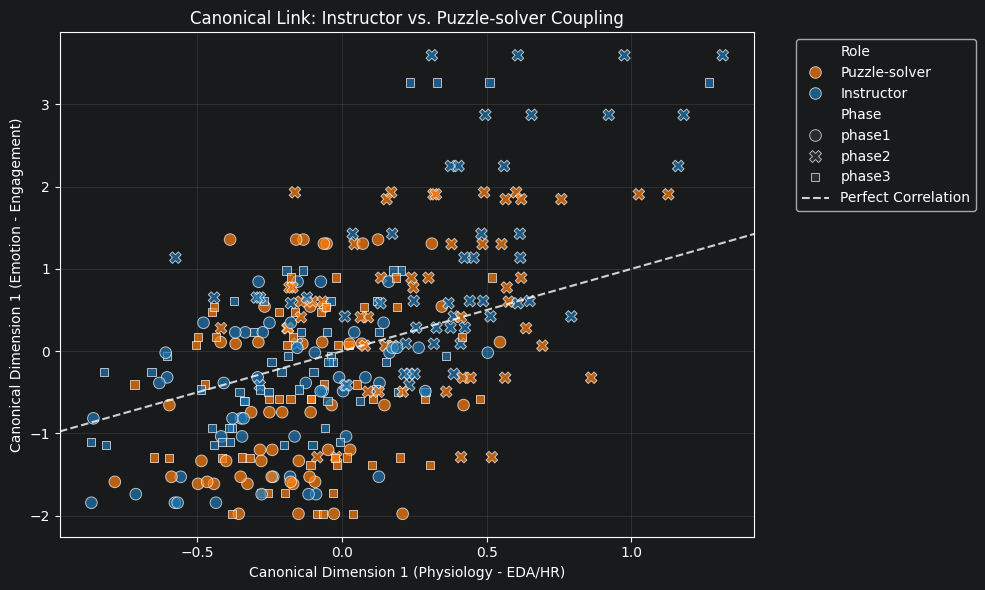

--- Correlation Comparison ---
Correlation for Instructor: 0.6733 (n=156)
Correlation for Puzzle-solver: 0.4475 (n=156)


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Update the analysis frame
df_analysis = df_ready.copy()
df_analysis['role_id'] = bundle['puzzler'][df_ready.index]

# Create clear names and add the CCA scores to the dataframe
df_analysis['Role'] = df_analysis['role_id'].map({0: 'Instructor', 1: 'Puzzle-solver'})
df_analysis['Physiology_Score'] = X_c[:, 0]
df_analysis['Emotion_Score'] = Y_c[:, 0]

# 2. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_analysis,  # This tells Seaborn to use your DataFrame
    x='Physiology_Score',
    y='Emotion_Score',
    hue='Role',
    style='Phase',
    palette={'Instructor': 'tab:blue', 'Puzzle-solver': 'tab:orange'},
    s=70, alpha=0.7
)

plt.axline((0, 0), slope=1, color="white", linestyle="--", linewidth=1.5, alpha=0.8, label='Perfect Correlation')
plt.title('Canonical Link: Instructor vs. Puzzle-solver Coupling')
plt.xlabel('Canonical Dimension 1 (Physiology - EDA/HR)')
plt.ylabel('Canonical Dimension 1 (Emotion - Engagement)')
plt.grid(True, alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR /'p2_cca_role_interaction.png', format='png', bbox_inches='tight')
plt.show()

# 3. Correlation Comparison
print("--- Correlation Comparison ---")
for role in ['Instructor', 'Puzzle-solver']:
    mask = df_analysis['Role'] == role
    if mask.sum() > 0:
        # Use the specific values from the filtered dataframe
        corr = np.corrcoef(df_analysis.loc[mask, 'Physiology_Score'],
                           df_analysis.loc[mask, 'Emotion_Score'])[0, 1]
        print(f"Correlation for {role}: {corr:.4f} (n={mask.sum()})")

## The Physiological Shadow (Thermal Recovery by Role)
Identify if the Thermal Drift (PC3) in the PCA is driven by the physical assembly (Solver) or the communicative stress (Instructor).

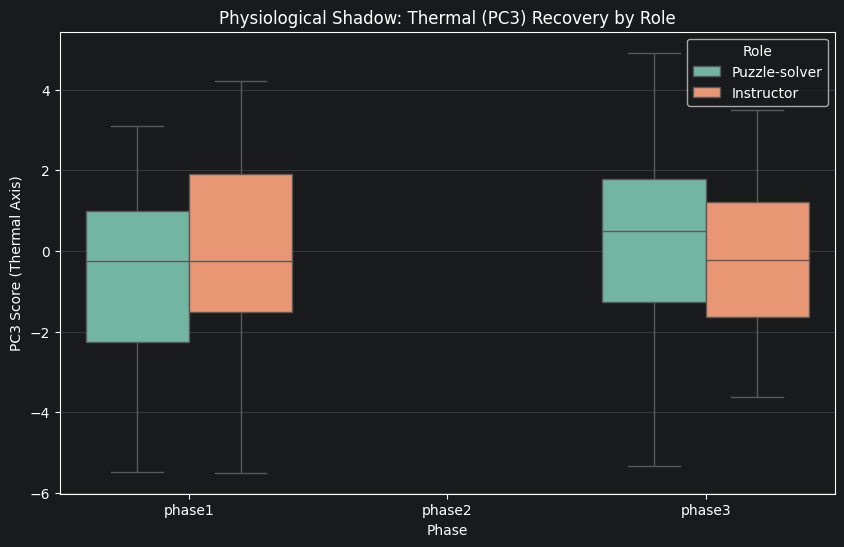

--- Mean PC3 Shift (Recovery - Baseline) ---
Instructor Drift: -0.0258
Puzzle-solver Drift: 0.7683


In [30]:
# 1. Attach PCA scores to the analysis dataframe
df_analysis['PC3'] = X_pca_3d[:, 2]

# 2. Pull role data directly from the bundle and map to names
# This ensures we don't get a KeyError
df_analysis['Role'] = pd.Series(bundle['puzzler'][df_ready.index]).map({0: 'Instructor', 1: 'Puzzle-solver'}).values

# 3. Filter for Baseline (Phase 1) and Recovery (Phase 3)
df_shadow = df_analysis[df_analysis['Phase'].isin(['phase1', 'phase3'])].copy()

# 4. Visualization
plt.figure(figsize=(10, 6))
# Using 'Role' for hue ensures the legend and colors match the data correctly
sns.boxplot(data=df_shadow, x='Phase', y='PC3', hue='Role', palette='Set2')

plt.title('Physiological Shadow: Thermal (PC3) Recovery by Role')
plt.ylabel('PC3 Score (Thermal Axis)')
plt.grid(axis='y', alpha=0.3)
plt.savefig(FIG_DIR /'p2_physiological_shadow_boxplot.png', format='png', bbox_inches='tight')
plt.show()

# 5. Quantitative Drift Analysis
print("--- Mean PC3 Shift (Recovery - Baseline) ---")
for role in ['Instructor', 'Puzzle-solver']:
    p1 = df_shadow[(df_shadow['Role'] == role) & (df_shadow['Phase'] == 'phase1')]['PC3'].mean()
    p3 = df_shadow[(df_shadow['Role'] == role) & (df_shadow['Phase'] == 'phase3')]['PC3'].mean()
    print(f"{role} Drift: {p3 - p1:.4f}")